In [2]:
#output results of parameter search and bifurcation analysis of AN network model  FigS4, S5

import os
import sys
import glob
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


           Model  Search_Total    SWS  Bifurcation (single)  \
0  SANAGNca_NaK1     100536331  43347                  3274   
0  SANAGNca_NaK1     167313136  72515                  2657   
0  SANAGNca_NaK1      62236332  37545                  2596   

   Bifurcation (network)  SWS/Total (%)  \
0                   1344       0.043116   
0                   1202       0.043341   
0                   1092       0.060326   

   Bifurcation (single neuron)/Total (%)  Bifurcation (single neuron)/SWS (%)  \
0                               0.003257                             7.553003   
0                               0.001588                             3.664070   
0                               0.004171                             6.914369   

   Bifurcation (network)/Total (%)  \
0                         0.001337   
0                         0.000718   
0                         0.001755   

   Bifurcation (network)/Bifurcation (single neuron) (%)  
0                                    

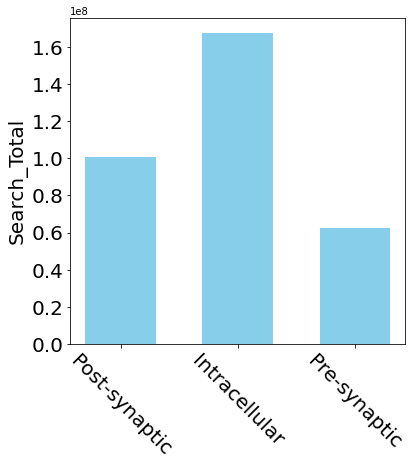

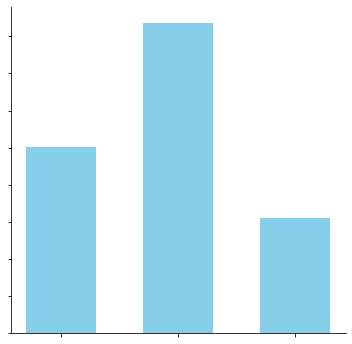

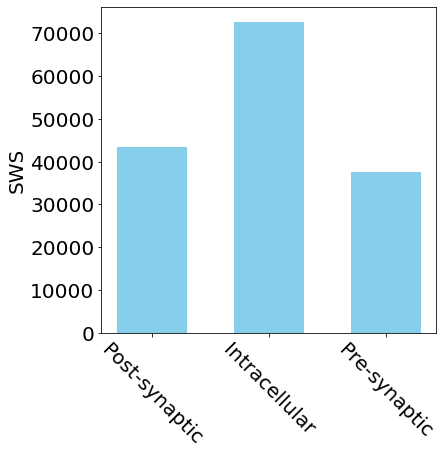

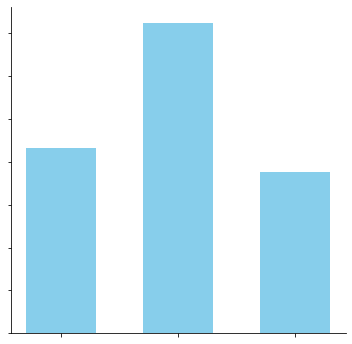

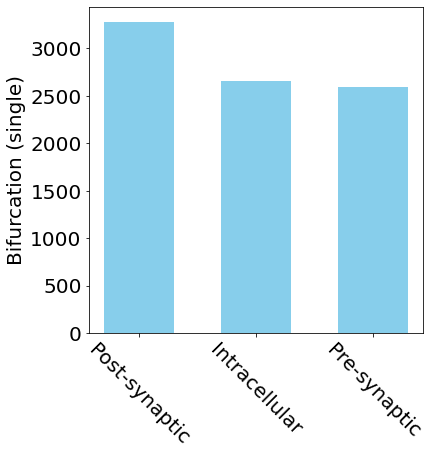

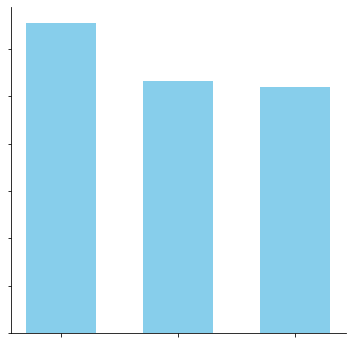

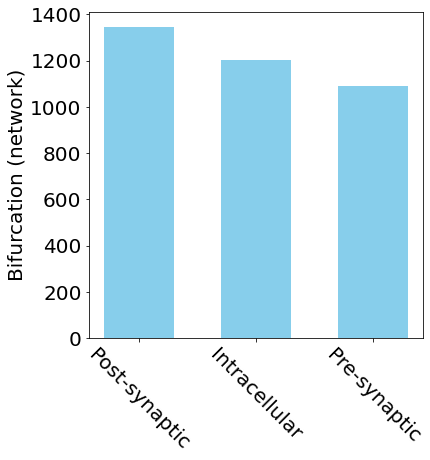

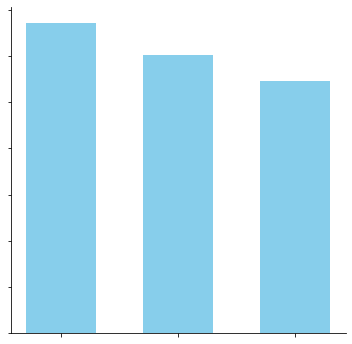

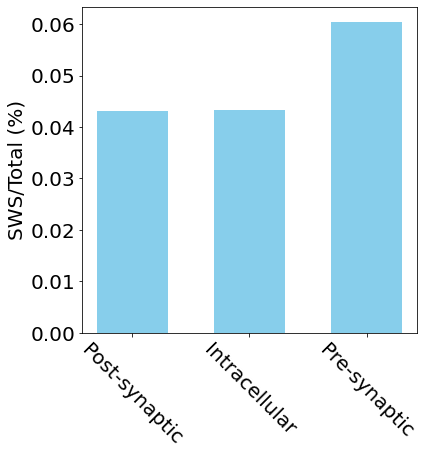

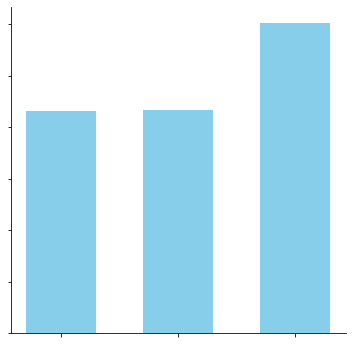

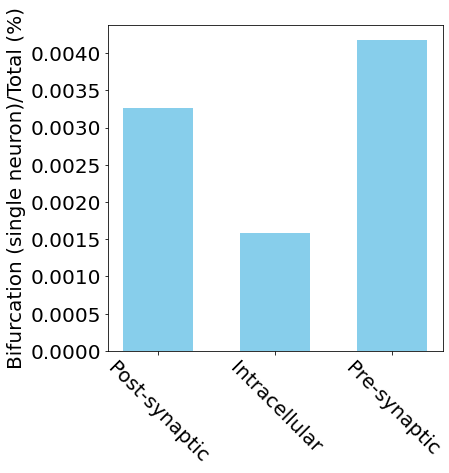

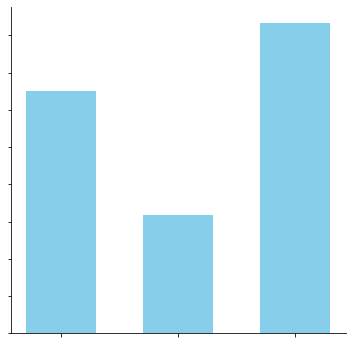

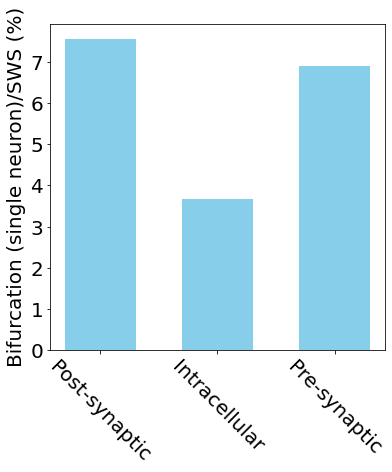

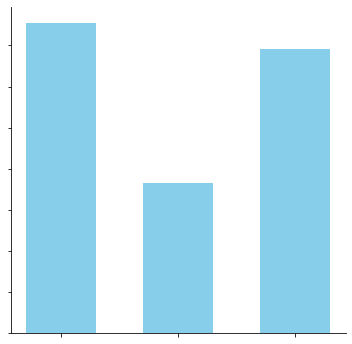

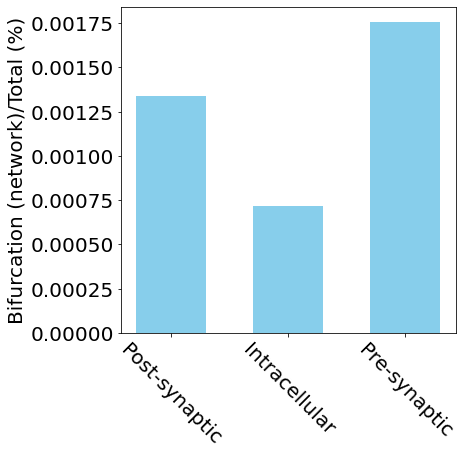

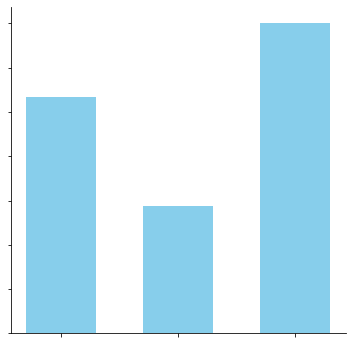

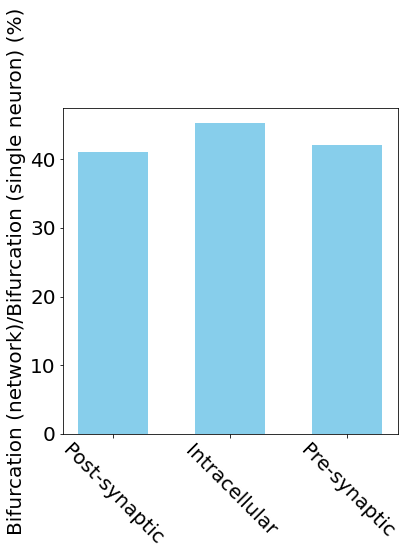

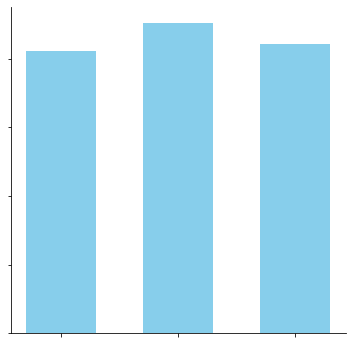

In [9]:
#collect number of sws and bifurcations by bifur_gs
rdir = "../AN_network/"

NE = 64  # number of excitatory neurons
NI = 16   # number of inhibitory neurons
con_M = 1.0  # mean for the lognormal distribution of the number of synapses per excitatory neuron
con_M_in =  1.0 # mean for the lognormal distribution of the number of synapses per inhibitory neuron
con_ex_ex = 0.01  # SD for the lognormal distribution of the number of synapses in Ex-Ex, Ex-in connections
con_in_in = 0.01 # SD for the lognormal distribution of the number of synapses in In-In, In-Ex connections
T =2500  #ms   simulation time
postfix = "NE{}_NI{}_conM{}_SD{}_conMin{}_inSD{}_T{}".format(NE,NI,con_M,con_ex_ex,con_M_in,con_in_in,T)

bifur_g_li =["_nmdar", "_cav", "_pre"]#, "_vGABAR"]
bifur_g_names =["Post-synaptic", "Intracellular", "Pre-synaptic"]#, "Ecl-"]
# bifur_g_li =["_nmdar", "_cav"]
# bifur_g_names =["NMDAR", "VDCC"]


model_pre = "AN" #args[8]
model_op="_net_bifurcation"
p_th = 0.01   #  >  ->wake
date_base_str = "2023_1_1"
# net_num=0
bifur_auto=True
savedir_col = rdir + "/net_col/"
os.makedirs(savedir_col, exist_ok = True)
df_col_li=[]

fs =20
fs_l=15

    
#plot graphs
for n, bifur_g in enumerate(bifur_g_li):
    df_col=pd.read_excel(savedir_col + model_pre+model_op+bifur_g+"_"+postfix+ "_total.xlsx",engine="openpyxl",index_col=0 )
    df_col_li.append(df_col)
    df_total = pd.concat(df_col_li)
print(df_total)

col_ps=["Search_Total", "SWS","Bifurcation (single)", "Bifurcation (network)", "SWS/Total (%)","Bifurcation (single neuron)/Total (%)","Bifurcation (single neuron)/SWS (%)","Bifurcation (network)/Total (%)","Bifurcation (network)/Bifurcation (single neuron) (%)"]
col_ts=["Search_Total", "SWS","Bifurcation (single)", "Bifurcation (network)", "SWSperTotal","Bifurcation (single neuron)perTotal","Bifurcation (single neuron)perSWS","Bifurcation (network)perTotal","Bifurcation (network)perBifurcation (single neuron)"]


for n,i in enumerate(col_ps):
    plt.figure(figsize=(10,6))
    plt.bar(bifur_g_names, df_total[i], color="skyblue",width = 0.6)
    plt.ylabel(i, fontsize = fs)
    
    plt.xlabel(i, fontsize = fs, rotation=45)
    
    plt.yticks(fontsize = fs)
    plt.xticks(fontsize = fs,rotation=-45)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    

    plt.savefig("{}_3ch.SVG".format(col_ts[n]))
    plt.show()

       PC1      PC2       PC3       PC4       PC5       PC6      PC7  \
0  0.20501  0.13666  0.089597  0.086428  0.077777  0.077253  0.06872   

        PC8       PC9      PC10      PC11      PC12      PC13  
0  0.062036  0.055561  0.053926  0.047256  0.033964  0.005812  


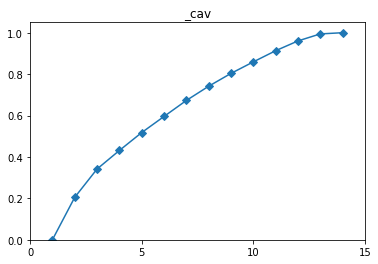

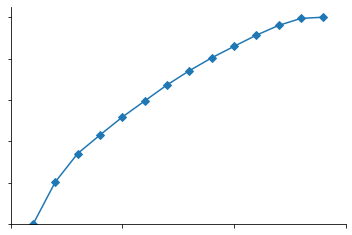

1202


In [4]:
#distribution and PCA of channels


from sklearn.decomposition import PCA

model_pre = "AN" #args[8]
model_op="_net_bifurcation"

bifur = "_cav"

df_bifur=pd.read_excel(savedir_col + model_pre+model_op+bifur+"_"+postfix+ "_bifur_params.xlsx",engine="openpyxl",index_col=0 )
# df_bifur=df_col[df_col["bifur"]==1]
# df_bifur.to_excel(savedir_col + model_pre+model_op+bifur_g+ "_bifur_params.xlsx")



df_g = df_bifur.iloc[:,0:13]
df_g_std = df_g.apply(lambda x: (x-x.mean())/x.std(), axis=0)

# df_g_std
pca = PCA()
pca.fit(df_g_std)

# データを主成分に変換
pca_row = pca.transform(df_g_std)

pca_col = ["PC{}".format(x + 1) for x in range(len(df_g_std.columns))]
df_con_ratio = pd.DataFrame([pca.explained_variance_ratio_], columns = pca_col)
print(df_con_ratio.head())

# 累積寄与率を図示する
cum_con_ratio = np.hstack([0, pca.explained_variance_ratio_]).cumsum()
x = np.arange(1, len(cum_con_ratio)+1, 1)

plt.plot(x, cum_con_ratio, 'D-')
plt.xticks(np.arange(0,20,5))
plt.yticks(np.arange(0,1.05,0.2))
plt.ylim(0,)
plt.xlim(0,)
plt.title(bifur.replace("_", ""))
# plt.grid()


#article

plt.xlabel('component',fontsize = fs)
plt.ylabel('Cumulative contribution rate', fontsize = fs)


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig("{}_PCA_cumlative_contribution.SVG".format(model_pre+model_op+bifur))
plt.show()



(1202, 13)


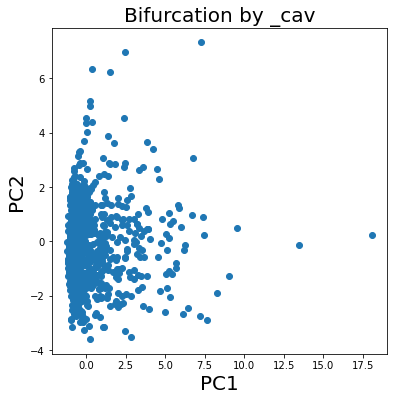

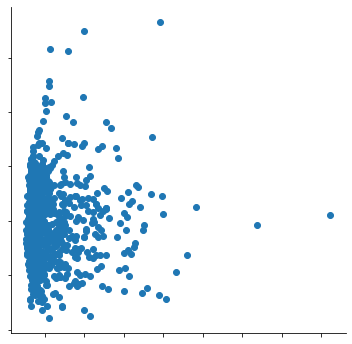

In [5]:
x_axis=0
y_axis=1
print(pca_row.shape)
plt.figure(figsize=(6, 6))
plt.scatter(pca_row[:,x_axis], pca_row[:,y_axis])
plt.title("Bifurcation by {}".format(bifur.replace("_", "")), fontsize=fs)
plt.xlabel("PC{}".format(x_axis+1), fontsize=fs)
plt.ylabel("PC{}".format(y_axis+1), fontsize=fs)


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig("{}_PCA_cluster.SVG".format(model_pre+model_op+bifur))
plt.show()